Using device: cpu
Trainable params: 1227
Epoch 0001 | train_mse=1.057247 | val_mse=0.861223
Epoch 0100 | train_mse=0.907575 | val_mse=0.808103
Epoch 0200 | train_mse=0.737018 | val_mse=0.634164
Epoch 0300 | train_mse=0.594073 | val_mse=0.504609
Epoch 0400 | train_mse=0.533536 | val_mse=0.461036
Epoch 0500 | train_mse=0.512016 | val_mse=0.450262
Epoch 0600 | train_mse=0.505187 | val_mse=0.447646
Epoch 0700 | train_mse=0.504198 | val_mse=0.447299

Test Metrics
MSE : 2786.2964
RMSE: 52.78538
R2  : 0.47410035133361816


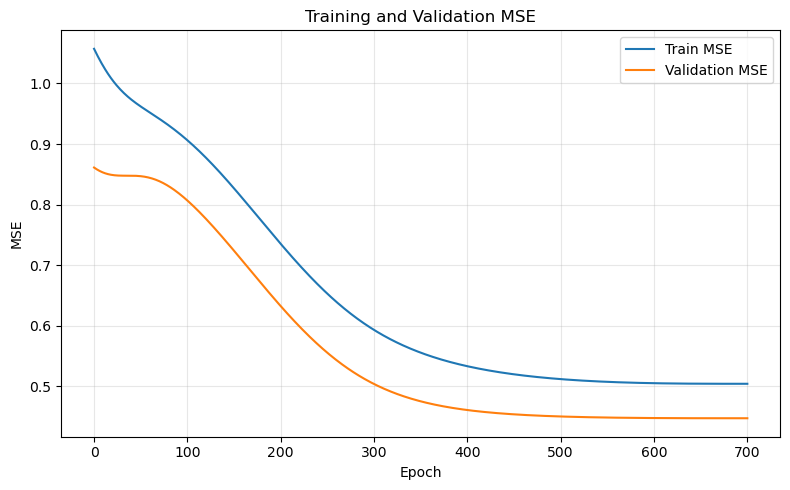

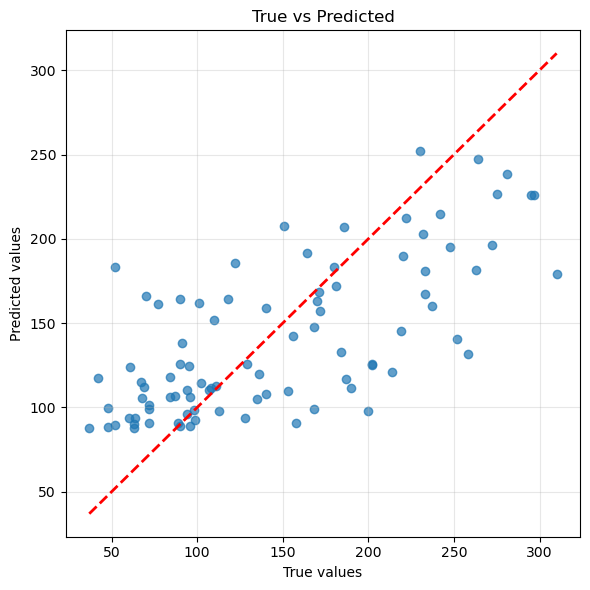

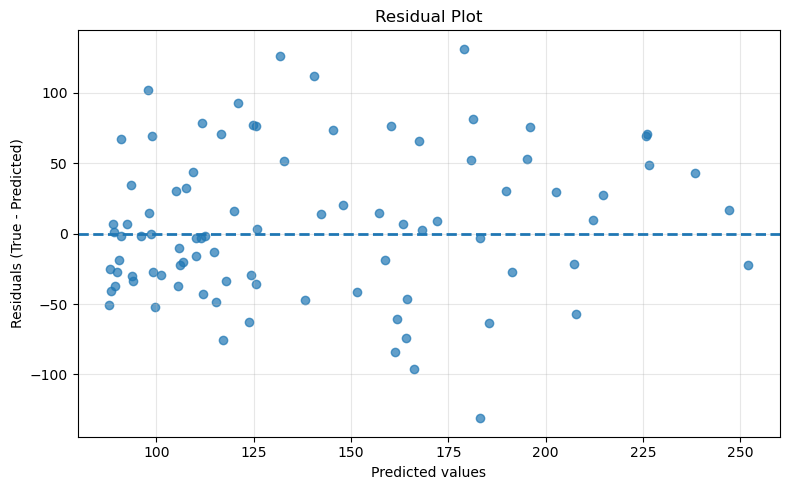

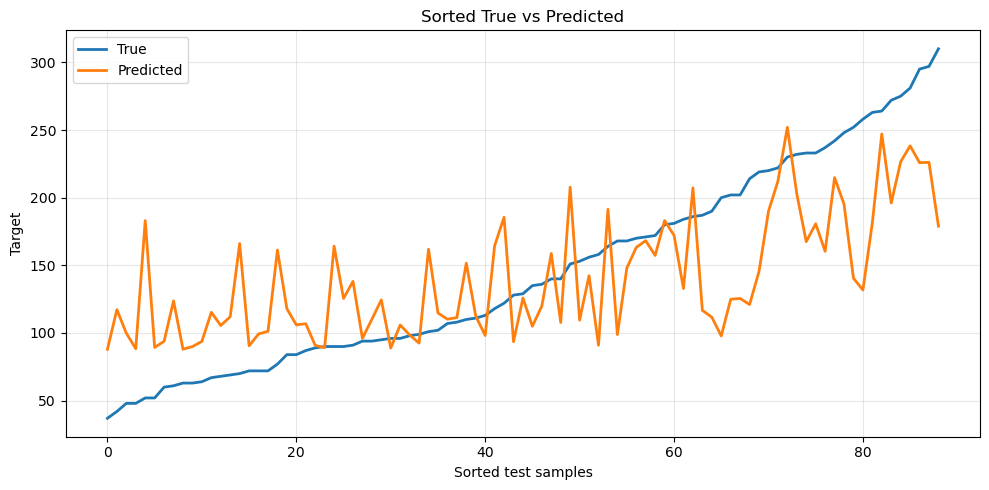

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from model_lmkan_rbf import LMKANRBF


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def load_regression_data(test_size=0.2, val_size=0.25, seed=42):
    # Example regression benchmark: Diabetes
    data = load_diabetes()
    X = data.data.astype(np.float32)                   # shape [N, 10]
    y = data.target.astype(np.float32).reshape(-1, 1)  # shape [N, 1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, random_state=seed
    )

    scaler_x = StandardScaler()
    X_train = scaler_x.fit_transform(X_train)
    X_val = scaler_x.transform(X_val)
    X_test = scaler_x.transform(X_test)

    # Helpful for regression stability
    scaler_y = StandardScaler()
    y_train = scaler_y.fit_transform(y_train)
    y_val = scaler_y.transform(y_val)
    y_test = scaler_y.transform(y_test)

    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
        scaler_y,
    )


def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=400,
    lr=1e-3,
    weight_decay=1e-5,
    patience=50,
    device="cpu",
):
    model = model.to(device)
    X_train, y_train = X_train.to(device), y_train.to(device)
    X_val, y_val = X_val.to(device), y_val.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    bad_epochs = 0

    history = {
        "train_mse": [],
        "val_mse": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train)
        loss = criterion(pred, y_train)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        train_loss = loss.item()
        history["train_mse"].append(train_loss)
        history["val_mse"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 100 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:04d} | "
                f"train_mse={train_loss:.6f} | "
                f"val_mse={val_loss:.6f}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, X_test, y_test, scaler_y, device="cpu"):
    model.eval()
    X_test, y_test = X_test.to(device), y_test.to(device)

    with torch.no_grad():
        pred = model(X_test)

    y_true = y_test.cpu().numpy()
    y_pred = pred.cpu().numpy()

    # Invert scaling to original units
    y_true_orig = scaler_y.inverse_transform(y_true).reshape(-1)
    y_pred_orig = scaler_y.inverse_transform(y_pred).reshape(-1)

    mse = mean_squared_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_orig, y_pred_orig)

    print("\nTest Metrics")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return y_true_orig, y_pred_orig, mse, rmse, r2


def plot_training_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_mse"], label="Train MSE")
    plt.plot(history["val_mse"], label="Validation MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("Training and Validation MSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_predictions(y_true, y_pred):
    # True vs Predicted scatter
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    min_v = min(y_true.min(), y_pred.min())
    max_v = max(y_true.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("True vs Predicted")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Residual plot
    residuals = y_true - y_pred
    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuals, alpha=0.7)
    plt.axhline(0, linestyle="--", linewidth=2)
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals (True - Predicted)")
    plt.title("Residual Plot")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Sorted comparison plot
    idx = np.argsort(y_true)
    plt.figure(figsize=(10, 5))
    plt.plot(y_true[idx], label="True", linewidth=2)
    plt.plot(y_pred[idx], label="Predicted", linewidth=2)
    plt.xlabel("Sorted test samples")
    plt.ylabel("Target")
    plt.title("Sorted True vs Predicted")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    X_train, y_train, X_val, y_val, X_test, y_test, scaler_y = load_regression_data()

    # Diabetes: 10 input features, 1 output
    model = LMKANRBF(
    in_dim=10,
    out_dim=1,
    width=8,
    depth=2,
    K=4,
    gamma=2.0,
    metric_hidden=8,
)

    print("Trainable params:", count_params(model))

    model, history = train_model(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=701,
        lr=2e-4,
        weight_decay=1e-3,
        patience=100,
        device=device,
    )

    y_true, y_pred, mse, rmse, r2 = evaluate_model(
        model, X_test, y_test, scaler_y, device=device
    )

    plot_training_history(history)
    plot_predictions(y_true, y_pred)


if __name__ == "__main__":
    main()